# Plotting Notebook (auto from artifacts)

This notebook loads the **latest** run exported by your analysis notebook and produces figures.
It is **name-agnostic**: it uses the `meta` attached to the artifacts (when available) to
find all summary tables and the "everything" table. It falls back to simple heuristics if
those keys are missing.


## Workflow

1. In the analysis notebook, run the export cell (right before any plotting) to write Parquet tables
   and a `meta.json` into a timestamped folder under `artifacts/`.
2. Open this notebook and run the cells top-to-bottom to generate figures from the latest run.
3. Figures are saved under `plots/<run_id>/` so every run remains reproducible.


In [2]:
# Load artifacts and resolve summary + everything tables
import os
import pandas as pd
from artifacts_io import load_artifacts
import seaborn as sns

tables, meta, run_dir = load_artifacts(out_dir="artifacts")
run_id = os.path.basename(run_dir)
print("Loaded run:", run_dir)
print("Meta:", meta)

# Resolve keys from meta if present; otherwise infer
summary_keys = meta.get("summary_keys", [])
everything_key = meta.get("everything_key")

if not summary_keys:
    # Heuristic: names containing common summary tokens
    name_hits = ("summary", "sum_", "_sum", "agg", "group", "pivot", "tbl", "by_", "_by")
    summary_keys = [k for k in tables if any(tok in k.lower() for tok in name_hits)]

if everything_key is None:
    # Largest table by rows as the 'everything' table
    everything_key = max(tables, key=lambda k: tables[k].shape[0])

print("\nResolved table keys:")
print("  summary_keys :", summary_keys if summary_keys else "(none)")
print("  everything_key:", everything_key)

# Preview heads
for k in tables:
    print(f"\nTable: {k}  shape={tables[k].shape}")
    display(tables[k].head(5))


Loaded run: artifacts\run_20250901_113434
Meta: {'created': '2025-09-01 11:34:34', 'n_tables': 4, 'notes': 'Dual-file processing: main + additional Santa Barbara datasets', 'source_notebook': 'working_datacrunch_sbaddition.ipynb', 'summary_keys': ['df_additional', 'df_additional_processed', 'df_main_processed', 'df_combined'], 'everything_key': 'df_combined', 'processing_type': 'dual_file_with_sb_additional', 'datasets': {'main': 'cleaned_metadata_final.csv', 'additional': 'final_sbmetadata.csv', 'combined': 'combined_metadata_with_years.csv'}}

Resolved table keys:
  summary_keys : ['df_additional', 'df_additional_processed', 'df_main_processed', 'df_combined']
  everything_key: df_combined

Table: df_additional  shape=(2312, 16)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,inferred_county,dates_of_recording,temporal_resolution,units_of_measurement,water_type,keyterms
0,sb3,2,34.4383,-119.5907,,,"Carpinteria, California",[],Carpinteria Basin,Santa Barbara County,Santa Barbara County,Unknown,Unknown,Not Specified,Groundwater,"['Carpinteria Basin', 'water levels']"
1,sb3,2,34.4389,-119.8373,,,"Goleta, California",[],Goleta Basin,Santa Barbara County,Santa Barbara County,Unknown,Unknown,Not Specified,Groundwater,"['Goleta Basin', 'water levels']"
2,sb3,2,34.6598,-120.0503,,,"Santa Ynez, California",[],Santa Ynez River Valley,Santa Barbara County,Santa Barbara County,Unknown,Unknown,Not Specified,Stream Discharge,"['Santa Ynez River Valley', 'water levels']"
3,sb3,2,34.9378,-120.1775,,,"Near San Antonio, California",[],San Antonio Creek Valley,Santa Barbara County,Santa Barbara County,Unknown,Unknown,Not Specified,Stream Discharge,"['San Antonio Creek Valley', 'water levels']"
4,sb3,2,34.9536,-120.4342,,,"Santa Maria, California",[],Santa Maria Valley,Santa Barbara County,Santa Barbara County,Unknown,Unknown,Not Specified,Groundwater,"['Santa Maria Valley', 'water levels']"



Table: df_additional_processed  shape=(2312, 28)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,latitude,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review
0,sb3,2,34.4383,-119.5907,,,"Carpinteria, California",[],Carpinteria Basin,Santa Barbara County,...,34.4383,-119.5907,Groundwater,None,<NA>,<NA>,None,UNPARSED,no_year_<=1980_found,True
1,sb3,2,34.4389,-119.8373,,,"Goleta, California",[],Goleta Basin,Santa Barbara County,...,34.4389,-119.8373,Groundwater,None,<NA>,<NA>,None,UNPARSED,no_year_<=1980_found,True
2,sb3,2,34.6598,-120.0503,,,"Santa Ynez, California",[],Santa Ynez River Valley,Santa Barbara County,...,34.6598,-120.0503,Stream discharge,None,<NA>,<NA>,None,UNPARSED,no_year_<=1980_found,True
3,sb3,2,34.9378,-120.1775,,,"Near San Antonio, California",[],San Antonio Creek Valley,Santa Barbara County,...,34.9378,-120.1775,Stream discharge,None,<NA>,<NA>,None,UNPARSED,no_year_<=1980_found,True
4,sb3,2,34.9536,-120.4342,,,"Santa Maria, California",[],Santa Maria Valley,Santa Barbara County,...,34.9536,-120.4342,Groundwater,None,<NA>,<NA>,None,UNPARSED,no_year_<=1980_found,True



Table: df_combined  shape=(109626, 28)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,latitude,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review
0,70038399,445,,,39.13472,-120.94833,"NEASE sec.22, T.15 N., R.9 E.","['T.15 N., R.9 E., SEC. 22']",Rollins Reservoir,Placer County,...,39.134720,-120.948330,Reservoir,None,1964,1966,"[1964, 1966]",EXACT_RANGE,None,False
1,553,177,,,35.933333,-118.483333,"NE sec. 14 T. 23 S., R. 32 E., 3 miles upstrea...","['T. 23 S., R. 32 E., NE sec. 14']",Kern River near Kernville,Tehama County,...,35.933333,-118.483333,Stream discharge,None,1912,1942,"[1912, 1942]",EXACT_RANGE,None,False
2,455,159,,,,,"Near La Grange, California",['3S 14E NE 1/4 sec. 3'],TUOLUMNE RIVER ABOVE LA GRANGE DAM,Tuolumne County,...,NaN,NaN,Stream discharge,None,1929,1930,"[1929, 1930]",EXACT_RANGE,None,False
3,251,43,,,32.81666667,-114.5,"Near Yuma, Arizona","['T. 15 S., R. 23 E.', 'SE1 sec. 10, T. 16 S.,...",Yuma Main Canal,Imperial County,...,32.816667,-114.500000,Stream discharge,None,1910,1938,"[1910, 1938]",EXACT_RANGE,None,False
4,2850,45,38.5,-122.0,,,Coyote Valley,,Putah Creek,,...,38.500000,-122.000000,Stream discharge,None,<NA>,<NA>,None,UNPARSED,None,True



Table: df_main_processed  shape=(107314, 28)


,id,page_number,inferred_latitude,inferred_longitude,actual_latitude,actual_longitude,location,townships_ranges_sections,watersource_name,actual_county,...,latitude,longitude,water_type_clean,water_type_review,year_start,year_end,years_list,date_parse_status,date_parse_notes,needs_date_review
0,70038399,445,,,39.13472,-120.94833,"NEASE sec.22, T.15 N., R.9 E.","['T.15 N., R.9 E., SEC. 22']",Rollins Reservoir,Placer County,...,39.134720,-120.948330,Reservoir,None,1964,1966,"[1964, 1966]",EXACT_RANGE,None,False
1,553,177,,,35.933333,-118.483333,"NE sec. 14 T. 23 S., R. 32 E., 3 miles upstrea...","['T. 23 S., R. 32 E., NE sec. 14']",Kern River near Kernville,Tehama County,...,35.933333,-118.483333,Stream discharge,None,1912,1942,"[1912, 1942]",EXACT_RANGE,None,False
2,455,159,,,,,"Near La Grange, California",['3S 14E NE 1/4 sec. 3'],TUOLUMNE RIVER ABOVE LA GRANGE DAM,Tuolumne County,...,NaN,NaN,Stream discharge,None,1929,1930,"[1929, 1930]",EXACT_RANGE,None,False
3,251,43,,,32.81666667,-114.5,"Near Yuma, Arizona","['T. 15 S., R. 23 E.', 'SE1 sec. 10, T. 16 S.,...",Yuma Main Canal,Imperial County,...,32.816667,-114.500000,Stream discharge,None,1910,1938,"[1910, 1938]",EXACT_RANGE,None,False
4,2850,45,38.5,-122.0,,,Coyote Valley,,Putah Creek,,...,38.500000,-122.000000,Stream discharge,None,<NA>,<NA>,None,UNPARSED,None,True


## Prep for mapping

In [3]:
# ==== Build combined coordinates from df_summary (actual > inferred) ====
import re
import numpy as np
import pandas as pd

# 0) Select the df_summary table from artifacts
if "tables" not in globals():
    raise RuntimeError("Run the artifacts loading cell first.")

if "df_main_processed" in tables:
    df_summary = tables["df_main_processed"].copy()
else:
    # case-insensitive match if key differs in case
    match_keys = [k for k in tables if k.lower() == "df_main_processed"]
    if not match_keys:
        raise KeyError("I can't find a table named 'df_main_processed' in artifacts.")
    df_summary = tables[match_keys[0]].copy()

print("df_main_processed shape:", df_summary.shape)

# ---------- Optional: set explicit column names here if you already know them ----------
# If you know the exact names, set them (strings) and this will override auto-detection below.
EXPLICIT_LAT_ACTUAL = None   # e.g., "Latitude_actual"
EXPLICIT_LAT_INFER  = None   # e.g., "Latitude_inferred"
EXPLICIT_LON_ACTUAL = None   # e.g., "Longitude_actual"
EXPLICIT_LON_INFER  = None   # e.g., "Longitude_inferred"
# -----------------------------------------------------------------------

def _coerce_num(s):
    return pd.to_numeric(s, errors="coerce")

def _first_nonnull(series_list, index):
    if not series_list:
        return pd.Series(index=index, dtype="float64")
    stacked = pd.concat([_coerce_num(s) for s in series_list], axis=1)
    return stacked.bfill(axis=1).iloc[:, 0]

def _find_cols(df, lat_or_lon, which):
    """
    lat_or_lon: 'lat' or 'lon'
    which: 'actual' or 'inferred'
    """
    pat_lat = r'(?:\blat\b|latitude)'
    pat_lon = r'(?:\blon\b|\blong\b|longitude)'
    pat_kind = r'actual' if which == "actual" else r'infer|inferred|estimat|approx'
    cols = []
    for c in df.columns:
        cl = c.lower()
        if (re.search(pat_lat, cl) if lat_or_lon=='lat' else re.search(pat_lon, cl)) and re.search(pat_kind, cl):
            cols.append(c)
    return cols

def _fallback_cols(df, lat_or_lon):
    pat = r'(?:\blat\b|latitude)' if lat_or_lon=='lat' else r'(?:\blon\b|\blong\b|longitude)'
    return [c for c in df.columns if re.search(pat, c.lower())]

# 1) Gather candidate columns (prefer explicit names if provided)
lat_actual_cols = [EXPLICIT_LAT_ACTUAL] if (EXPLICIT_LAT_ACTUAL and EXPLICIT_LAT_ACTUAL in df_summary.columns) else _find_cols(df_summary, 'lat','actual')
lat_infer_cols  = [EXPLICIT_LAT_INFER]  if (EXPLICIT_LAT_INFER  and EXPLICIT_LAT_INFER  in df_summary.columns) else _find_cols(df_summary, 'lat','inferred')
lon_actual_cols = [EXPLICIT_LON_ACTUAL] if (EXPLICIT_LON_ACTUAL and EXPLICIT_LON_ACTUAL in df_summary.columns) else _find_cols(df_summary, 'lon','actual')
lon_infer_cols  = [EXPLICIT_LON_INFER]  if (EXPLICIT_LON_INFER  and EXPLICIT_LON_INFER  in df_summary.columns) else _find_cols(df_summary, 'lon','inferred')

# Fallbacks if column names don’t contain 'actual'/'inferred'
if not (lat_actual_cols or lat_infer_cols):
    lat_infer_cols = _fallback_cols(df_summary, 'lat')
if not (lon_actual_cols or lon_infer_cols):
    lon_infer_cols = _fallback_cols(df_summary, 'lon')

lat_names_order = lat_actual_cols + lat_infer_cols
lon_names_order = lon_actual_cols + lon_infer_cols

lat_sources = [df_summary[c] for c in lat_names_order if c in df_summary.columns]
lon_sources = [df_summary[c] for c in lon_names_order if c in df_summary.columns]

if not lat_sources or not lon_sources:
    raise ValueError("Couldn’t find latitude/longitude columns. If you know them, set the EXPLICIT_* names above.")

# 2) Build combined columns (actual → inferred)
df_summary["lat_combined"] = _first_nonnull(lat_sources, df_summary.index)
df_summary["lon_combined"] = _first_nonnull(lon_sources, df_summary.index)

# 3) Normalize longitudes and fix obvious lat/lon swaps
def _normalize_lon(x):
    # bring into [-180, 180]
    return ((x + 180) % 360) - 180

if (df_summary["lon_combined"] > 180).mean() > 0.2:
    df_summary["lon_combined"] = _normalize_lon(df_summary["lon_combined"])

swap_mask = (~df_summary["lat_combined"].between(-90, 90)) & (df_summary["lon_combined"].between(-90, 90))
if swap_mask.any():
    df_summary.loc[swap_mask, ["lat_combined","lon_combined"]] = (
        df_summary.loc[swap_mask, ["lon_combined","lat_combined"]].to_numpy()
    )

# 4) Record which source column was used (NaN-safe)
def _first_used_name(series_list, names):
    out = np.full(len(df_summary), np.nan, dtype=object)
    for s, n in zip(series_list, names):
        take = pd.isna(out) & ~_coerce_num(s).isna()
        out[take.values] = n
    return pd.Series(out, index=df_summary.index)

df_summary["lat_source_col"] = _first_used_name([df_summary[c] for c in lat_names_order], lat_names_order) if lat_names_order else np.nan
df_summary["lon_source_col"] = _first_used_name([df_summary[c] for c in lon_names_order], lon_names_order) if lon_names_order else np.nan

def _safe_tag(val):
    if not isinstance(val, str):
        return "unspecified"
    v = val.lower()
    if "actual" in v:
        return "actual"
    if "infer" in v or "estimat" in v or "approx" in v:
        return "inferred"
    return "unspecified"

df_summary["coord_source"] = [
    _safe_tag(la) if _safe_tag(la) == _safe_tag(lo) else f"{_safe_tag(la)}/{_safe_tag(lo)}"
    for la, lo in zip(df_summary["lat_source_col"], df_summary["lon_source_col"])
]

# 5) Drop invalid coordinates
valid = df_summary["lat_combined"].between(-90, 90) & df_summary["lon_combined"].between(-180, 180)
dropped = (~valid).sum()
df_summary = df_summary.loc[valid].copy()

print(f"Combined coordinates built. Dropped {dropped} rows with invalid/missing coords.")
print("coord_source breakdown:")
print(df_summary["coord_source"].value_counts(dropna=False))
print("Preview:")
display(df_summary[[
    *(lat_names_order[:1] or []), *(lon_names_order[:1] or []),
    "lat_combined","lon_combined","coord_source"
]].head(10))



df_main_processed shape: (107314, 28)
Combined coordinates built. Dropped 7772 rows with invalid/missing coords.
coord_source breakdown:
coord_source
actual             57616
inferred           41912
actual/inferred        8
inferred/actual        6
Name: count, dtype: int64
Preview:


,actual_latitude,actual_longitude,lat_combined,lon_combined,coord_source
0,39.13472,-120.94833,39.134720,-120.948330,actual
1,35.933333,-118.483333,35.933333,-118.483333,actual
3,32.81666667,-114.5,32.816667,-114.500000,actual
4,,,38.500000,-122.000000,inferred
5,,,38.500000,-122.000000,inferred
6,,,38.500000,-122.000000,inferred
7,,,38.500000,-122.000000,inferred
8,,,38.696900,-121.767200,inferred
9,36.216111,-118.871667,36.216111,-118.871667,actual
10,,,35.333300,-118.516700,inferred


## Set color scheme for water type

In [4]:
# ==== WATER TYPE FILTERING AND CONSISTENT COLOR SETUP ====
print(f"\n=== WATER TYPE FILTERING ===")

# Check current water_type_clean distribution
if 'water_type_clean' in df_summary.columns:
    print("Current water_type_clean distribution:")
    water_counts = df_summary['water_type_clean'].value_counts(dropna=False)
    print(water_counts)
    
    # Filter out unwanted categories
    exclude_categories = ['Not water related', 'Other']
    
    # Create mask to keep only water-related categories
    water_mask = ~df_summary['water_type_clean'].isin(exclude_categories)
    
    # Apply filter
    df_summary_before = len(df_summary)
    df_summary = df_summary[water_mask].copy()
    df_summary_after = len(df_summary)
    
    excluded_count = df_summary_before - df_summary_after
    
    print(f"\nFiltering results:")
    print(f"  - Before filtering: {df_summary_before:,} rows")
    print(f"  - After filtering: {df_summary_after:,} rows") 
    print(f"  - Excluded: {excluded_count:,} rows ({excluded_count/df_summary_before*100:.1f}%)")
    
    print(f"\nRemaining water categories:")
    remaining_counts = df_summary['water_type_clean'].value_counts(dropna=False)
    print(remaining_counts)
    
else:
    print("WARNING: 'water_type_clean' column not found!")

# ==== CONSISTENT COLOR PALETTE SETUP ====
print(f"\n=== CONSISTENT COLOR PALETTE SETUP ===")

# Define the consistent colorblind-friendly palette
colorblind_safe_colors = [
    '#4477AA',  # blue
    '#EE6677',  # red
    '#228833',  # green  
    '#CCBB44',  # yellow
    '#66CCEE',  # cyan
    '#AA3377',  # purple
    '#332288',  # dark purple
    '#99DDFF',  # light blue
    '#44BB99',  # teal
    '#DDCC77'   # beige
]

def create_consistent_color_mapping(gdf_ca, cat_col):
    """Create consistent color mapping based on category frequency"""
    cat_counts = gdf_ca[cat_col].value_counts()
    cats_by_freq = cat_counts.index.tolist()
    
    # Map categories to colors by frequency
    color_mapping = dict(zip(cats_by_freq, colorblind_safe_colors[:len(cats_by_freq)]))
    
    print("Color mapping (most to least common):")
    for cat in cats_by_freq:
        print(f"  {cat}: {color_mapping[cat]} ({cat_counts[cat]:,} points)")
    
    return color_mapping, cats_by_freq

# Create initial GeoDataFrame to set up colors
import geopandas as gpd
gdf_temp = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# Set up the global color mapping that will be used throughout
GLOBAL_COLOR_MAPPING, GLOBAL_CATS_BY_FREQ = create_consistent_color_mapping(gdf_temp, 'water_type_clean')
print("="*50)


=== WATER TYPE FILTERING ===
Current water_type_clean distribution:
water_type_clean
Stream discharge     72639
Groundwater          16216
Reservoir             4245
Irrigation            2109
Springs               1891
Precipitation          861
None                   833
Not water related      502
Water quality          239
Other                    7
Name: count, dtype: int64

Filtering results:
  - Before filtering: 99,542 rows
  - After filtering: 99,033 rows
  - Excluded: 509 rows (0.5%)

Remaining water categories:
water_type_clean
Stream discharge    72639
Groundwater         16216
Reservoir            4245
Irrigation           2109
Springs              1891
Precipitation         861
None                  833
Water quality         239
Name: count, dtype: int64

=== CONSISTENT COLOR PALETTE SETUP ===
Color mapping (most to least common):
  Stream discharge: #4477AA (72,639 points)
  Groundwater: #EE6677 (16,216 points)
  Reservoir: #228833 (4,245 points)
  Irrigation: #CCBB44 (2

## Flag and filter rows outside of CA

In [5]:
# ==== Flag rows outside California; robust with fallback to CA bounding box ====
import os
import geopandas as gpd
import numpy as np

# Build GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# Try Natural Earth states first
ca_geom = None
try:
    import geodatasets
    state_keys = [
        "naturalearth.cultural.admin_1_states_provinces",                  # polygons
        "naturalearth.cultural.ne_10m_admin_1_states_provinces",           # polygons
        "naturalearth.cultural.admin_1_states_provinces_lines",            # lines (we'll buffer)
        "naturalearth.cultural.ne_10m_admin_1_states_provinces_lines",     # lines (we'll buffer)
        "naturalearth.cultural.ne_50m_admin_1_states_provinces_lines",
    ]
    states = None
    for key in state_keys:
        try:
            states = gpd.read_file(geodatasets.get_path(key)).to_crs("EPSG:4326")
            break
        except Exception:
            continue
    if states is not None:
        # If we loaded a line layer, turn it into a thin polygon via buffer
        if states.geom_type.iloc[0].lower().endswith("line"):
            # small buffer (~0.05 deg) to create a polygon surface
            states = states.buffer(0.05)
            states = gpd.GeoDataFrame(geometry=states, crs="EPSG:4326")
            states["name"] = np.nan  # no names available on some line layers

        # Try common name fields for California
        name_col = None
        for cand in ["name", "name_en", "name_long", "adm1name", "region"]:
            if cand in states.columns:
                name_col = cand
                break
        if name_col is not None:
            ca = states[states[name_col].astype(str).str.contains("California", case=False, na=False)]
        else:
            ca = gpd.GeoDataFrame(columns=states.columns, geometry=[], crs=states.crs)

        if not ca.empty:
            ca_geom = ca.unary_union
except Exception:
    pass  # we'll fall back below

# Fallback: tight California bounding box (state extremes; includes offshore, but good for QA)
from shapely.geometry import box
if ca_geom is None:
    # California geographic extremes (approx):
    # West/East: -124.48 to -114.13 ; South/North: 32.45 to 42.01
    ca_geom = box(-124.48, 32.45, -114.13, 42.01)

# Compute in/out
within_ca = gdf.within(ca_geom)
gdf["in_california"] = within_ca

outside_ca = gdf.loc[~within_ca].copy()

print(f"Total rows: {len(gdf):,}")
print(f"Inside California: {int(within_ca.sum()):,}")
print(f"Outside California: {len(outside_ca):,}")

# Preview a few suspicious rows
preview_cols = [c for c in ["site","site_id","name","station","coord_source","lat_combined","lon_combined"] if c in gdf.columns]
display(outside_ca.head(20)[preview_cols] if preview_cols else outside_ca.head(20))

# Export for review in the original data file
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)
out_csv = os.path.join(outdir, "sites_outside_CA.csv")
outside_ca.drop(columns="geometry").to_csv(out_csv, index=False)
print("Exported rows outside California to:", out_csv)


Total rows: 99,033
Inside California: 91,124
Outside California: 7,909


,coord_source,lat_combined,lon_combined
29,inferred,41.150000,-111.970000
37,actual,31.746100,-110.566900
50,actual,42.150000,-121.700000
51,actual,42.133300,-121.966700
67,actual,42.233333,-120.500000
76,actual,42.500000,-111.316667
78,inferred,33.147800,-111.732100
102,actual,34.366700,-111.783300
109,actual,38.041667,-111.450000
110,actual,38.001389,-111.389444


Exported rows outside California to: plots\run_20250901_113434\sites_outside_CA.csv


## CA only plots

Total rows: 99,033 | California-only: 88,174

=== DECADE INFORMATION FOR ORIGINAL DATA (DF_SUMMARY) ===
'decade' column not found in dataset
Available columns: ['id', 'page_number', 'inferred_latitude', 'inferred_longitude', 'actual_latitude', 'actual_longitude', 'location', 'townships_ranges_sections', 'watersource_name', 'actual_county', 'inferred_county', 'dates_of_recording_raw', 'temporal_resolution', 'units_of_measurement', 'water_type', 'keyterms', 'data_source', 'id_page_number', 'latitude', 'longitude', 'water_type_clean', 'water_type_review', 'year_start', 'year_end', 'years_list', 'date_parse_status', 'date_parse_notes', 'needs_date_review', 'lat_combined', 'lon_combined', 'lat_source_col', 'lon_source_col', 'coord_source']

=== DECADE INFORMATION FOR CALIFORNIA-ONLY DATA (GDF_CA) ===
'decade' column not found in dataset
Available columns: ['id', 'page_number', 'inferred_latitude', 'inferred_longitude', 'actual_latitude', 'actual_longitude', 'location', 'townships_ranges_sec

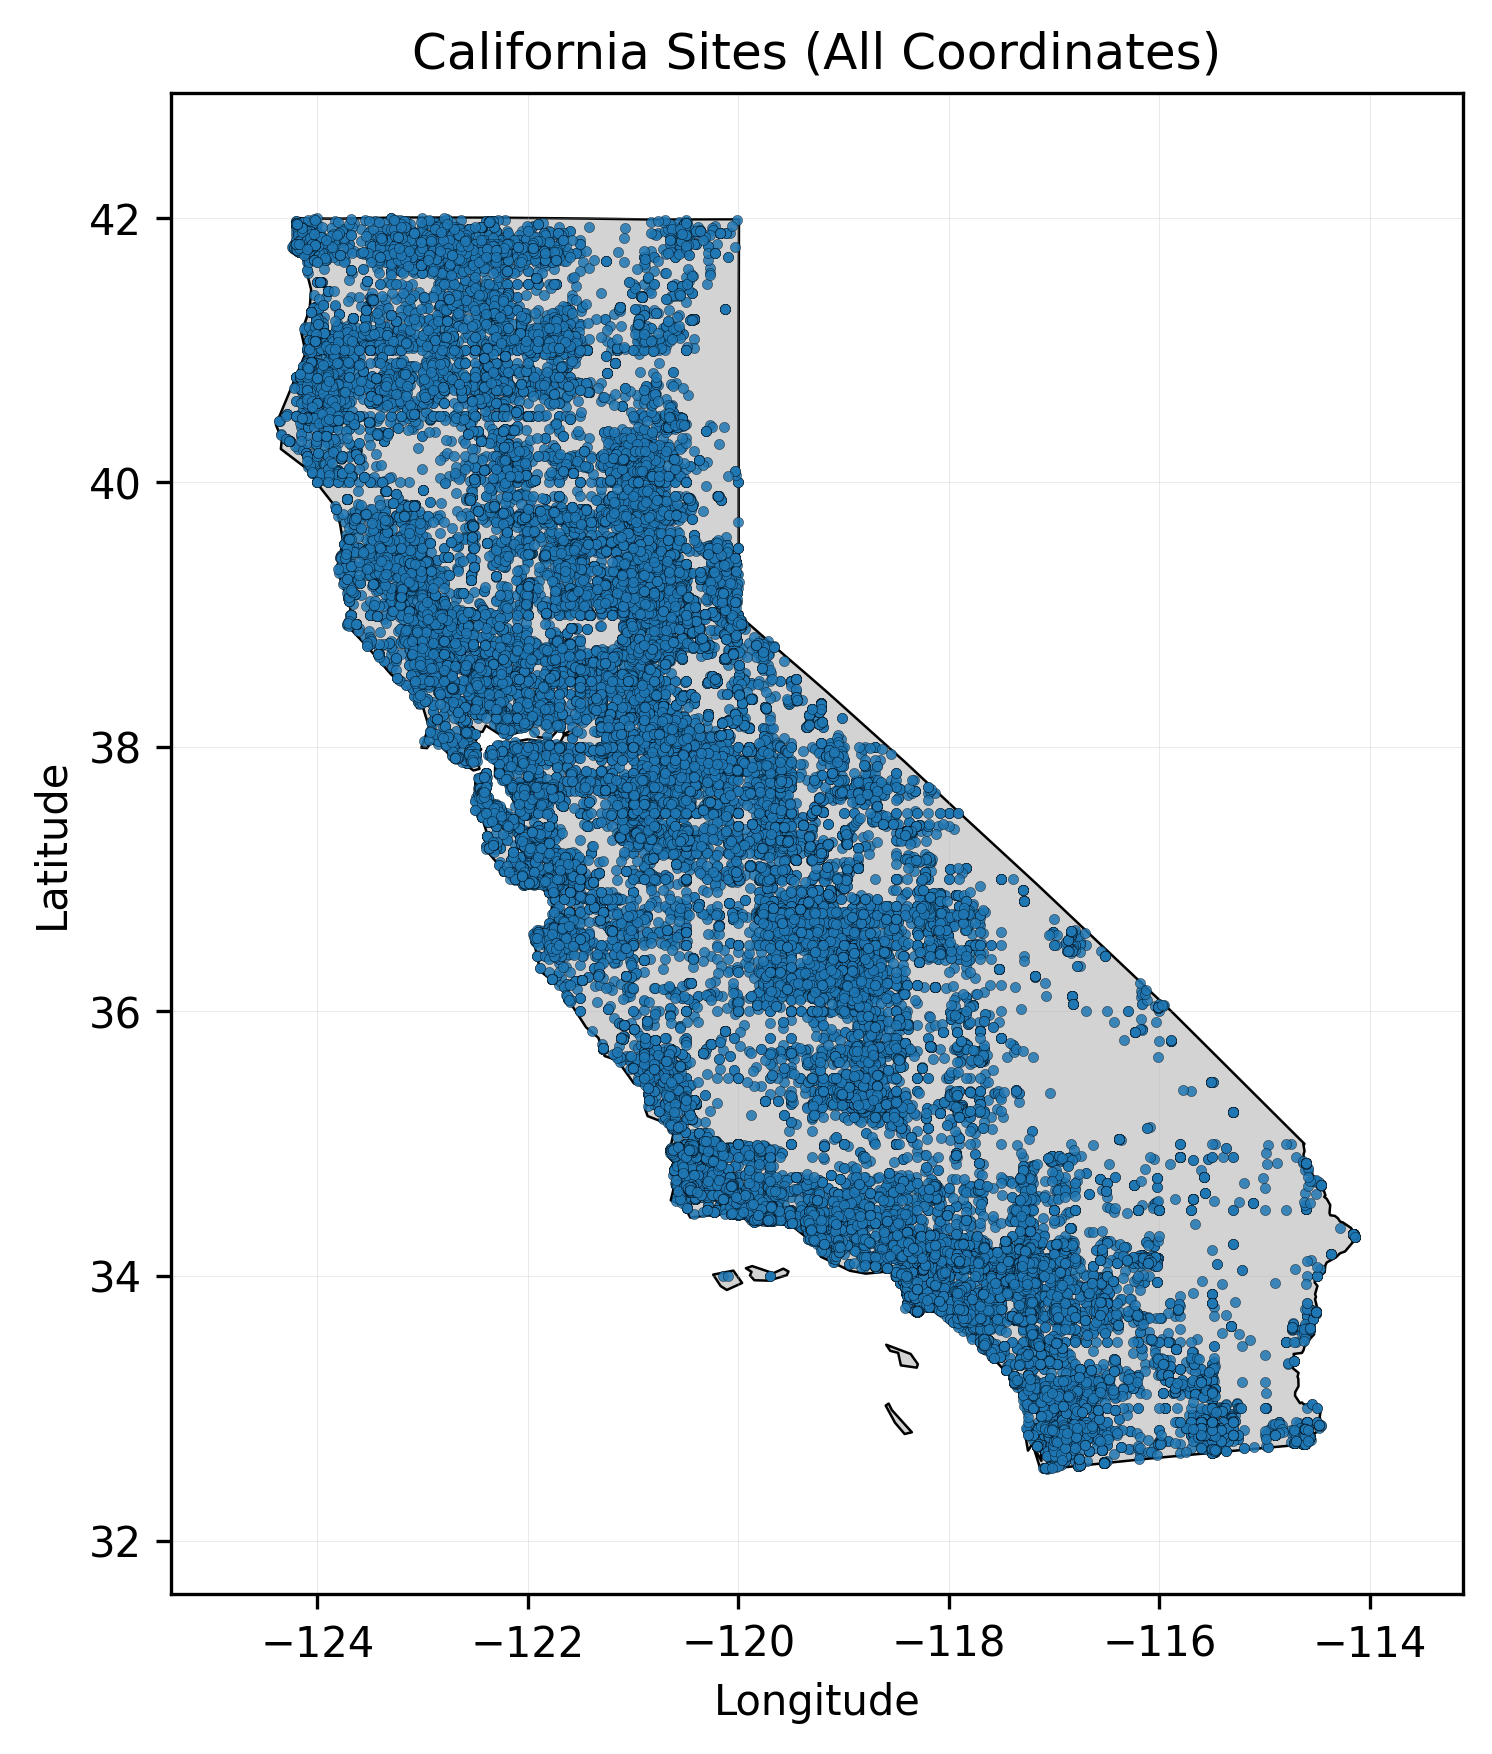

Saved: plots\run_20250901_113434\CA_ONLY_all_sites_static_ACTUAL_vs_INFERRED.png


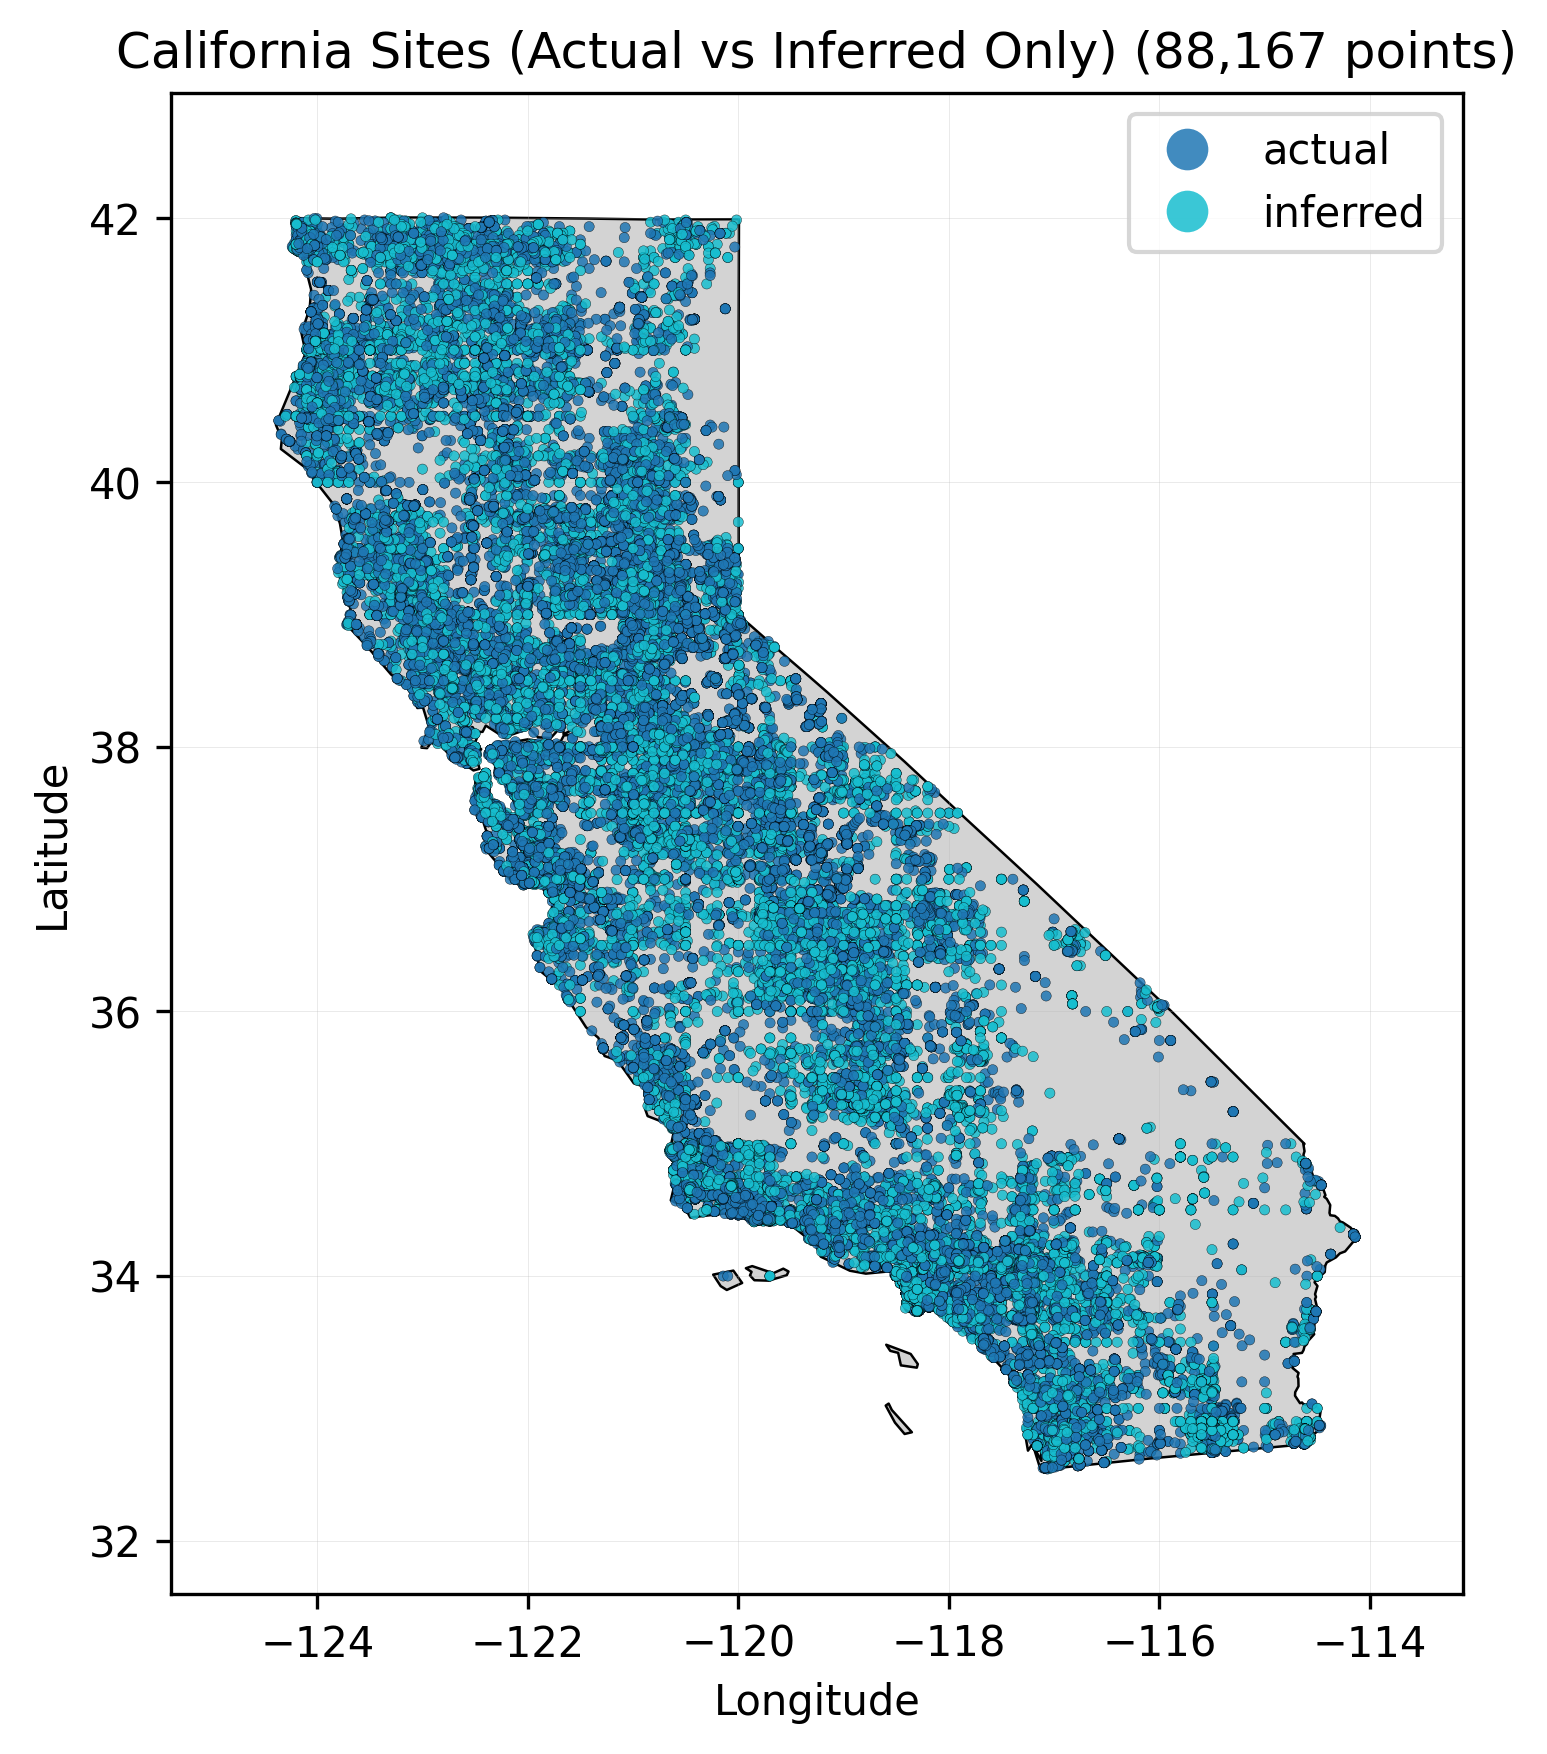

In [10]:
# ==== California-only maps using your ca_poly.shp shapefile ====
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box

# 0) Path to your shapefile
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"

# 1) Load CA polygon; ensure valid geometry and CRS = EPSG:4326
ca = gpd.read_file(path_to_ca)
if ca.empty:
    raise RuntimeError(f"No features found in {path_to_ca}")

if hasattr(ca, "is_valid") and not ca.is_valid.all():
    ca = ca.buffer(0)
    ca = gpd.GeoDataFrame(geometry=ca, crs=gpd.read_file(path_to_ca).crs)

# Reproject to WGS84 lat/lon if needed
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined. Please check the .prj file.")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")

# Dissolve to a single polygon (Shapely 2.x safe)
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union

# 2) Build GeoDataFrame of points
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# 3) Filter to California
in_ca = gdf.within(ca_poly)
gdf_ca = gdf.loc[in_ca].copy()
print(f"Total rows: {len(gdf):,} | California-only: {len(gdf_ca):,}")

if len(gdf_ca) == 0:
    raise RuntimeError("No points fall inside California based on your shapefile.")

# 4) Data-driven extent with generous padding
minx, miny, maxx, maxy = gdf_ca.total_bounds
pad_lon = max(0.5, (maxx - minx) * 0.10)
pad_lat = max(0.5, (maxy - miny) * 0.10)
xmin, ymin, xmax, ymax = (minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# 5) Output folder
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)

# Create the actual vs inferred subset BEFORE the decade analysis
mask_ai = gdf_ca["coord_source"].isin(["actual", "inferred"])
gdf_ca_ai = gdf_ca.loc[mask_ai].copy()

# DECADE ANALYSIS SECTION - Now placed after all dataframes are created
def print_decade_info(df, data_name="dataset"):
    """Print decade range information for the dataset"""
    if df is None or len(df) == 0:
        print(f"\n=== DECADE INFORMATION FOR {data_name.upper()} ===")
        print("Dataset is empty or None")
        return
    
    if 'decade' in df.columns:
        decades = df['decade'].dropna()
        if not decades.empty:
            decade_min = decades.min()
            decade_max = decades.max()
            unique_decades = sorted(decades.unique())
            print(f"\n=== DECADE INFORMATION FOR {data_name.upper()} ===")
            print(f"Decade range: {decade_min} - {decade_max}")
            print(f"Unique decades: {unique_decades}")
            print(f"Number of records per decade:")
            decade_counts = decades.value_counts().sort_index()
            for decade, count in decade_counts.items():
                print(f"  {decade}: {count:,} records")
            print(f"Total records with decade info: {len(decades):,}")
        else:
            print(f"\n=== DECADE INFORMATION FOR {data_name.upper()} ===")
            print("No non-null decade values found")
    else:
        print(f"\n=== DECADE INFORMATION FOR {data_name.upper()} ===")
        print("'decade' column not found in dataset")
        print("Available columns:", list(df.columns))

# Print decade info for your California datasets
print_decade_info(df_summary, "Original Data (df_summary)")
print_decade_info(gdf_ca, "California-only Data (gdf_ca)")

# Check the filtered actual/inferred California data
if len(gdf_ca_ai) > 0:
    print_decade_info(gdf_ca_ai, "California Actual vs Inferred Data (gdf_ca_ai)")
else:
    print("\n=== California Actual vs Inferred Data (gdf_ca_ai) ===")
    print("No actual/inferred records found in California data")

# Alternative: If decade column might be named differently, check for similar columns
print("\n=== CHECKING FOR DECADE-RELATED COLUMNS ===")
decade_like_cols = [col for col in df_summary.columns if 'decade' in col.lower() or 'year' in col.lower() or 'date' in col.lower()]
if decade_like_cols:
    print("Found potential time-related columns:", decade_like_cols)
    # Show sample values for each time-related column
    for col in decade_like_cols:
        sample_vals = df_summary[col].dropna().head(5).tolist()
        print(f"  {col}: sample values = {sample_vals}")
else:
    print("No decade/year/date columns found in df_summary")

# ---------- MAP A: All CA points ----------
fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=300)

gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0)

gdf_ca.plot(
    ax=ax,
    color="C0",
    markersize=6,
    alpha=0.85,
    edgecolor="k",
    linewidth=0.1,
    zorder=2,
)

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_title("California Sites (All Coordinates)", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, linewidth=0.2, alpha=0.3)

outfile_A = os.path.join(outdir, "CA_ONLY_all_sites_static_ALL.png")
plt.savefig(outfile_A, dpi=300, bbox_inches="tight")
print("Saved:", outfile_A)
plt.show()

# ---------- MAP B: CA only — Actual vs Inferred ----------
fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=300)

gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0)

if len(gdf_ca_ai) > 0:
    gdf_ca_ai.plot(
        ax=ax,
        column="coord_source",
        categorical=True,
        legend=True,
        markersize=6,
        alpha=0.85,
        edgecolor="k",
        linewidth=0.1,
        zorder=2,
    )
    title_suffix = f"({len(gdf_ca_ai):,} points)"
else:
    print("Warning: No actual/inferred points to plot")
    title_suffix = "(No actual/inferred points found)"

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_title(f"California Sites (Actual vs Inferred Only) {title_suffix}", fontsize=12)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, linewidth=0.2, alpha=0.3)

outfile_B = os.path.join(outdir, "CA_ONLY_all_sites_static_ACTUAL_vs_INFERRED.png")
plt.savefig(outfile_B, dpi=300, bbox_inches="tight")
print("Saved:", outfile_B)
plt.show()

## California by water type 

In [ ]:
# ==== California-only map colored by water_type_clean (filtered) with US context ====
import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# Path to your CA shapefile
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"

# 1) Load California polygon (Shapely 2.x safe) and ensure WGS84
ca = gpd.read_file(path_to_ca)
if ca.empty:
    raise RuntimeError(f"No features found in {path_to_ca}")
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined. Please check the .prj file.")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union

# 2) Load US outline for context (continental US shape only)
try:
    import geodatasets
    # Get the overall US outline (country level, not states)
    us_outline = gpd.read_file(geodatasets.get_path("naturalearth.land")).to_crs("EPSG:4326")
    print("Loaded continental US outline from naturalearth.land")
except Exception:
    try:
        # Alternative: try the countries dataset and filter for US
        world = gpd.read_file(geodatasets.get_path("naturalearth.lowres")).to_crs("EPSG:4326")
        us_outline = world[world['name'] == 'United States of America']
        print("Loaded US from world countries dataset")
    except Exception:
        try:
            # Third attempt: try different naturalearth dataset
            us_outline = gpd.read_file(geodatasets.get_path("naturalearth.cultural.admin_0_countries")).to_crs("EPSG:4326")
            us_outline = us_outline[us_outline['NAME'].str.contains('United States', na=False)]
            print("Loaded US from admin_0_countries dataset")
        except Exception as e:
            print(f"Could not load US outline: {e}")
            print("Proceeding with California-only map")
            us_outline = None

# 3) Points GeoDataFrame (WGS84)
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)

# 4) Keep only points inside California
in_ca = gdf.within(ca_poly)
gdf_ca = gdf.loc[in_ca].copy()
if len(gdf_ca) == 0:
    raise RuntimeError("No points fall inside California based on your shapefile.")

# 5) Filter water_type_clean
cat_col = "water_type_clean"
if cat_col not in gdf_ca.columns:
    raise KeyError(f"Column '{cat_col}' not found in df_summary.")

gdf_ca[cat_col] = gdf_ca[cat_col].astype(str).replace({"nan": "Unknown"}).fillna("Unknown")

# Remove unwanted categories
drop_vals = {"not water related", "other"}
gdf_ca = gdf_ca[~gdf_ca[cat_col].str.lower().isin(drop_vals)].copy()

print("Categories retained:", gdf_ca[cat_col].unique())

# 6) Padded extent so nothing gets clipped (same as before)
minx, miny, maxx, maxy = gdf_ca.total_bounds
pad_lon = max(0.5, (maxx - minx) * 0.10)
pad_lat = max(0.5, (maxy - miny) * 0.10)
xmin, ymin, xmax, ymax = (minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# 7) Get category counts and sort by frequency (most common first)
cat_counts = gdf_ca[cat_col].value_counts()
cats_by_freq = cat_counts.index.tolist()

print("Categories by frequency (most to least common):")
for cat in cats_by_freq:
    print(f"  {cat}: {cat_counts[cat]:,} points")

# 8) Colorblind-friendly palette with dark purple instead of gray
colorblind_safe_colors = [
    '#4477AA',  # blue
    '#EE6677',  # red
    '#228833',  # green  
    '#CCBB44',  # yellow
    '#66CCEE',  # cyan
    '#AA3377',  # purple
    '#332288',  # dark purple (instead of gray)
    '#99DDFF',  # light blue
    '#44BB99',  # teal
    '#DDCC77'   # beige
]

color_mapping = dict(zip(cats_by_freq, colorblind_safe_colors[:len(cats_by_freq)]))

# 9) Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=300)

# Plot US outline context first (if available)
if us_outline is not None:
    us_outline.plot(
        ax=ax, 
        color="#f0f0f0",  # Very light gray for context
        edgecolor="white", 
        linewidth=0.3, 
        zorder=0
    )

# CA background polygon - slightly darker than US outline to highlight it
gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(
    ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=1
)

# Plot points by frequency (most common FIRST, so they're on bottom)
for cat in cats_by_freq:  # most common plots first (bottom layer)
    sub = gdf_ca[gdf_ca[cat_col] == cat]
    if len(sub) == 0:
        continue
    sub.plot(
        ax=ax,
        color=color_mapping[cat],
        markersize=6,           # keeping original size
        alpha=0.75,             # transparency
        zorder=2,
        label=cat
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Remove axes labels, ticks, and spines for cleaner look
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Add light gray border around the entire image
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#cccccc')  # Light gray color
    spine.set_linewidth(1.0)

# Remove grid
ax.grid(False)

# Legend positioned closer to California (upper right area)
ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),  # Close to upper right corner
    borderaxespad=0.0,
    ncol=1,  # Single column looks cleaner without axis labels
    markerscale=3.0,
    frameon=True,
    fancybox=True,
    shadow=False,
    framealpha=0.9
)

# 10) Save
outdir = os.path.join("plots", run_id)
os.makedirs(outdir, exist_ok=True)
outfile = os.path.join(outdir, "CA_ONLY_by_water_type_filtered.png")
plt.savefig(outfile, dpi=300, bbox_inches="tight")
print("Saved:", outfile)

plt.show()

# ==== ADDITIONAL FIGURES FOR INFOGRAPHIC ====
# Add this code after your existing plotting code

# 11) California-only map with transparent background, no legend
fig2, ax2 = plt.subplots(figsize=(9, 7), dpi=300)

# Make background transparent
fig2.patch.set_alpha(0.0)
ax2.patch.set_alpha(0.0)

# CA outline only - with black edge for clarity
gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(
    ax=ax2, 
    facecolor='none',  # No fill, just outline
    edgecolor="black", 
    linewidth=1.2, 
    zorder=1
)

# Plot points by frequency (most common FIRST, so they're on bottom)
for cat in cats_by_freq:
    sub = gdf_ca[gdf_ca[cat_col] == cat]
    if len(sub) == 0:
        continue
    sub.plot(
        ax=ax2,
        color=color_mapping[cat],
        markersize=6,
        alpha=0.75,
        zorder=2
    )

ax2.set_xlim(xmin, xmax)
ax2.set_ylim(ymin, ymax)

# Remove all axes elements
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xlabel("")
ax2.set_ylabel("")

# Hide all spines
for spine in ax2.spines.values():
    spine.set_visible(False)

# Remove grid
ax2.grid(False)

# No legend for this version

# Save with transparent background
ca_only_file = os.path.join(outdir, "CA_ONLY_transparent_no_legend.png")
plt.savefig(ca_only_file, dpi=300, bbox_inches="tight", transparent=True)
print("Saved CA-only transparent map:", ca_only_file)

plt.show()

# 12) Separate legend as standalone PNG
fig3, ax3 = plt.subplots(figsize=(3, 4), dpi=300)

# Make background transparent
fig3.patch.set_alpha(0.0)
ax3.patch.set_alpha(0.0)

# Hide the axes completely
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# Create dummy plots just for legend
legend_handles = []
for cat in cats_by_freq:
    handle = ax3.scatter([], [], 
                        color=color_mapping[cat], 
                        s=100,  # Larger for legend visibility
                        alpha=0.9, 
                        label=cat)
    legend_handles.append(handle)

# Create legend
legend = ax3.legend(
    handles=legend_handles,
    loc="center",
    bbox_to_anchor=(0.5, 0.5),
    borderaxespad=0.0,
    ncol=1,
    markerscale=1.5,
    frameon=True,
    fancybox=True,
    shadow=False,
    framealpha=0.9,
    fontsize=12
)

# Style the legend frame
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('lightgray')
legend.get_frame().set_linewidth(1)

# Save legend only
legend_file = os.path.join(outdir, "legend_only.png")
plt.savefig(legend_file, dpi=300, bbox_inches="tight", transparent=True)
print("Saved standalone legend:", legend_file)

plt.show()

print("\nInfographic files created:")
print(f"1. CA map (transparent, no legend): {ca_only_file}")
print(f"2. Standalone legend: {legend_file}")
print(f"3. Original map: {outfile}")

## Individual maps for each water type 

In [ ]:
# ==== One map per water_type_clean category with CONSISTENT COLORS ====
import os
import matplotlib.pyplot as plt
import geopandas as gpd

# Path to your CA shapefile
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"

# Load California polygon
ca = gpd.read_file(path_to_ca)
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined.")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union

# Build GeoDataFrame and filter to CA
gdf = gpd.GeoDataFrame(
    df_summary,
    geometry=gpd.points_from_xy(df_summary["lon_combined"], df_summary["lat_combined"]),
    crs="EPSG:4326"
)
gdf_ca = gdf.loc[gdf.within(ca_poly)].copy()

# Filter water_type_clean
cat_col = "water_type_clean"
drop_vals = {"not water related", "other"}
gdf_ca[cat_col] = gdf_ca[cat_col].astype(str).replace({"nan": "Unknown"}).fillna("Unknown")
gdf_ca = gdf_ca[~gdf_ca[cat_col].str.lower().isin(drop_vals)].copy()

# Compute padded extent
minx, miny, maxx, maxy = gdf_ca.total_bounds
pad_lon = max(0.5, (maxx - minx) * 0.10)
pad_lat = max(0.5, (maxy - miny) * 0.10)
xmin, ymin, xmax, ymax = (minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# Output folder
outdir = os.path.join("plots", run_id, "by_water_type")
os.makedirs(outdir, exist_ok=True)

# Loop through categories with CONSISTENT colors
categories = sorted(gdf_ca[cat_col].unique())
print(f"Making {len(categories)} individual maps with consistent colors...")

for cat in categories:
    sub = gdf_ca[gdf_ca[cat_col] == cat]
    
    fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=300)
    
    # Background CA polygon
    gpd.GeoSeries([ca_poly], crs="EPSG:4326").plot(
        ax=ax, color="lightgray", edgecolor="black", linewidth=0.6, zorder=0
    )
    
    # Plot with CONSISTENT color
    sub.plot(
        ax=ax,
        color=GLOBAL_COLOR_MAPPING[cat],  # KEY CHANGE: Use consistent color!
        markersize=6,
        alpha=0.9,
        edgecolor="k",
        linewidth=0.1,
        zorder=2,
    )
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"California Sites: {cat}", fontsize=12)
    ax.set_xlabel("")  # Remove axis labels
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    
    # Add light gray border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(1.0)
    
    # Save with safe filename
    safe_cat = "".join(c if c.isalnum() or c in ("_", "-") else "_" for c in cat)
    outfile = os.path.join(outdir, f"CA_sites_{safe_cat}.png")
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close(fig)
    
    print(f"Saved: {outfile} (color: {GLOBAL_COLOR_MAPPING[cat]})")

## By decade

## New code 08/21

In [20]:
# ==== California-only maps by DECADE, colored by water_type_clean ====
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# --- CONFIG ---
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
cat_col    = "water_type_clean"
drop_vals  = {"not water related", "other"}  # filter these out
dpi = 300

# --- Helper function to calculate decades ---
def calculate_decade(year):
    """Calculate decade from year (e.g., 1823 -> 1820)"""
    if pd.isna(year):
        return np.nan
    try:
        year_int = int(float(year))
        return (year_int // 10) * 10
    except (ValueError, TypeError):
        return np.nan

# --- Add decade column if it doesn't exist ---
def ensure_decade_column(df, year_col='year'):
    """Ensure decade column exists in dataframe"""
    if 'decade' not in df.columns:
        if year_col in df.columns:
            print(f"Creating 'decade' column from '{year_col}' column...")
            df['decade'] = df[year_col].apply(calculate_decade)
            print(f"Decade column created. Sample values: {df['decade'].dropna().head().tolist()}")
        else:
            # Try to find a year-like column
            year_cols = [col for col in df.columns if 'year' in col.lower()]
            if year_cols:
                print(f"Found potential year columns: {year_cols}")
                print(f"Using '{year_cols[0]}' to create decade column...")
                df['decade'] = df[year_cols[0]].apply(calculate_decade)
            else:
                raise KeyError(f"No 'decade' column found and no '{year_col}' column to derive it from. Available columns: {list(df.columns)}")
    else:
        print("Decade column already exists")
    
    return df

# --- Load California polygon (Shapely 2.x safe) ---
ca = gpd.read_file(path_to_ca)
if ca.empty:
    raise RuntimeError(f"No features found in {path_to_ca}")
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined (.prj missing?).")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union

# --- Use df_main_processed as the data source ---
try:
    main_df = df_summary
    coord_df = df_summary
    print("Using df_main_processed as data source")
except NameError:
    raise NameError("df_main_processed is not defined. Please define your main dataframe.")

# --- Ensure decade column exists ---
main_df = ensure_decade_column(main_df.copy())

# --- Build points GeoDataFrame ---
required_cols = ['lon_combined', 'lat_combined']
missing_cols = [col for col in required_cols if col not in coord_df.columns]
if missing_cols:
    # Try alternative column names
    lon_cols = [col for col in coord_df.columns if 'lon' in col.lower()]
    lat_cols = [col for col in coord_df.columns if 'lat' in col.lower()]
    
    if lon_cols and lat_cols:
        print(f"Using {lon_cols[0]} and {lat_cols[0]} for coordinates")
        lon_col, lat_col = lon_cols[0], lat_cols[0]
    else:
        raise KeyError(f"Missing coordinate columns: {missing_cols}. Available columns: {list(coord_df.columns)}")
else:
    lon_col, lat_col = 'lon_combined', 'lat_combined'

gdf = gpd.GeoDataFrame(
    main_df,
    geometry=gpd.points_from_xy(coord_df[lon_col], coord_df[lat_col]),
    crs="EPSG:4326"
)

# --- Filter to California only (in WGS84) ---
in_ca = gdf.within(ca_poly)
gdf_ca = gdf.loc[in_ca].copy()
print(f"Total points: {len(gdf):,} | California points: {len(gdf_ca):,}")

if len(gdf_ca) == 0:
    raise RuntimeError("No points fall inside California based on your shapefile.")

# --- Filter categories ---
if cat_col not in gdf_ca.columns:
    raise KeyError(f"Column '{cat_col}' not found. Available columns: {list(gdf_ca.columns)}")

gdf_ca[cat_col] = gdf_ca[cat_col].astype(str).replace({"nan": "Unknown"}).fillna("Unknown")
gdf_ca = gdf_ca[~gdf_ca[cat_col].str.lower().isin(drop_vals)].copy()
print(f"After filtering categories: {len(gdf_ca):,} points")

# --- Guard: need decade column ---
if "decade" not in gdf_ca.columns:
    raise KeyError("Column 'decade' not found after processing.")

# --- Create color mapping if not defined ---
try:
    # Check if global variables are defined
    test_vars = [GLOBAL_CATS_BY_FREQ, GLOBAL_COLOR_MAPPING]
    print("Using predefined global color mapping")
except NameError:
    print("Creating color mapping from data...")
    # Get categories by frequency
    cat_counts = gdf_ca[cat_col].value_counts()
    GLOBAL_CATS_BY_FREQ = cat_counts.index.tolist()
    
    # Create color mapping using matplotlib's tab10 colormap
    import matplotlib.cm as cm
    colors = plt.cm.tab10(np.linspace(0, 1, len(GLOBAL_CATS_BY_FREQ)))
    GLOBAL_COLOR_MAPPING = {cat: colors[i] for i, cat in enumerate(GLOBAL_CATS_BY_FREQ)}
    
    print(f"Created color mapping for {len(GLOBAL_CATS_BY_FREQ)} categories:")
    for cat in GLOBAL_CATS_BY_FREQ:
        print(f"  {cat}: {cat_counts[cat]} points")

# --- Set run_id if not defined ---
try:
    test_run_id = run_id
except NameError:
    import datetime
    run_id = f"decade_analysis_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    print(f"Created run_id: {run_id}")

# --- NOW project to California Albers (after filtering) ---
CA_ALBERS = "EPSG:3310"  # California Albers projection
ca_series_proj = gpd.GeoSeries([ca_poly], crs="EPSG:4326").to_crs(CA_ALBERS)
gdf_ca_proj = gdf_ca.to_crs(CA_ALBERS)

# Use projected bounds
ca_bounds_proj = ca_series_proj.total_bounds
xmin, ymin, xmax, ymax = ca_bounds_proj
print(f"Projected bounds: {xmin:.0f}, {ymin:.0f}, {xmax:.0f}, {ymax:.0f}")

# --- Print decade information ---
decades_all = sorted(gdf_ca_proj["decade"].dropna().unique())
print(f"\nDECADE ANALYSIS:")
print(f"All available decades: {decades_all}")
print(f"Decade range: {min(decades_all)} - {max(decades_all)}")

decade_counts = gdf_ca_proj["decade"].value_counts().sort_index()
print("Records per decade:")
for decade, count in decade_counts.items():
    print(f"  {int(decade)}: {count:,} records")

# --- Use the global consistent color mapping ---
print(f"\nUsing color mapping for decade maps:")
for cat in GLOBAL_CATS_BY_FREQ:
    print(f"  {cat}: {GLOBAL_COLOR_MAPPING[cat]}")

# --- Output dirs ---
outdir = os.path.join("plots", run_id, "by_decade")
os.makedirs(outdir, exist_ok=True)

# --- Filter to decades up to 1980 (<=1979) ---
decades = [d for d in decades_all if d <= 1979]
print(f"\nFiltered to decades ≤1979: Found {len(decades)} decades: {decades}")

if len(decades) == 0:
    print("WARNING: No decades found ≤1979. Using all available decades.")
    decades = decades_all

# --- Calculate grid size to accommodate all decades (no separate legend panel) ---
n_decades = len(decades)

# Calculate optimal grid dimensions (prefer more columns than rows)
ncols = min(4, max(3, int(np.ceil(np.sqrt(n_decades * 1.2)))))  # Prefer 3-4 columns
nrows = int(np.ceil(n_decades / ncols))

print(f"Creating {nrows}x{ncols} grid for {n_decades} decades")
print(f"Grid size: {nrows * ncols}")

# Adjust figure size based on grid, with extra space at bottom for legend
base_width = 2.5  # width per column
base_height = 2.0  # height per row
legend_height = 0.8  # extra space for bottom legend
fig_width = ncols * base_width
fig_height = nrows * base_height + legend_height

print(f"Figure size: {fig_width:.1f} x {fig_height:.1f} inches")

# --- Create dynamic grid layout ---
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_width, fig_height), dpi=dpi)

# Handle single row case
if nrows == 1:
    axes = axes.reshape(1, -1)
elif ncols == 1:
    axes = axes.reshape(-1, 1)
    
axes = axes.flatten()

plt.subplots_adjust(
    left=0,
    bottom=0.12,  # Leave space at bottom for legend
    right=0.82,
    top=1,
    wspace=0,
    hspace=0
)

# Plot all decades
for idx, dec in enumerate(decades):
    ax = axes[idx]
    sub_proj = gdf_ca_proj[gdf_ca_proj["decade"] == dec]
    
    print(f"Decade {int(dec)}: {len(sub_proj)} points")

    # CA background (projected)
    ca_series_proj.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.5, zorder=0)
    
    # Plot points by frequency using projected data
    for cat in GLOBAL_CATS_BY_FREQ:
        s = sub_proj[sub_proj[cat_col] == cat]
        if len(s) == 0: 
            continue
        s.plot(
            ax=ax, 
            color=GLOBAL_COLOR_MAPPING[cat],
            markersize=3,
            alpha=0.75,
            edgecolor='none',
            linewidth=0,
            zorder=2
        )

    # Use projected bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    # Equal aspect ratio works better with projected coordinates
    ax.set_aspect('equal')
    
    # Position title in upper right corner
    ax.text(0.95, 0.95, f"{int(dec)}", transform=ax.transAxes, 
            fontsize=10, ha='right', va='top', 
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Add light gray border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#dddddd')
        spine.set_linewidth(0.5)
    
    ax.grid(False)

# Create horizontal legend at bottom spanning the full figure
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', linestyle='',
                  markerfacecolor=GLOBAL_COLOR_MAPPING[c], markeredgecolor='none',
                  markersize=8, label=c)
           for c in GLOBAL_CATS_BY_FREQ]

# Calculate number of columns for legend (2 categories per line)
legend_ncols = 2
fig.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=legend_ncols,
    frameon=True,
    fancybox=True,
    shadow=False,
    framealpha=0.9,
    fontsize=9,
    markerscale=1.0,
    columnspacing=2.0,
    handletextpad=0.5
)

# Hide unused axes (all decades now fit in the main grid)
for idx in range(n_decades, len(axes)):
    axes[idx].axis('off')

out_png = os.path.join(outdir, "CA_by_water_type_through_1979_albers_projection.png")
plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
plt.close(fig)
print(f"\nSaved Albers projected decade map: {out_png}")

# Print final summary
print(f"\nFINAL SUMMARY:")
print(f"Total California points plotted: {len(gdf_ca_proj):,}")
print(f"Decades plotted: {len(decades)} (all available ≤1979)")
print(f"Grid size: {nrows}x{ncols} = {nrows * ncols} panels")
print(f"Legend: {len(GLOBAL_CATS_BY_FREQ)} categories in {legend_ncols} columns at bottom")
print(f"Output directory: {outdir}")

Using df_main_processed as data source
Found potential year columns: ['year_start', 'year_end', 'years_list']
Using 'year_start' to create decade column...
Total points: 99,033 | California points: 88,174
After filtering categories: 88,174 points
Using predefined global color mapping
Projected bounds: -372554, -604342, 540519, 449913

DECADE ANALYSIS:
All available decades: [np.float64(1810.0), np.float64(1820.0), np.float64(1840.0), np.float64(1850.0), np.float64(1860.0), np.float64(1870.0), np.float64(1880.0), np.float64(1890.0), np.float64(1900.0), np.float64(1910.0), np.float64(1920.0), np.float64(1930.0), np.float64(1940.0), np.float64(1950.0), np.float64(1960.0), np.float64(1970.0), np.float64(1980.0)]
Decade range: 1810.0 - 1980.0
Records per decade:
  1810: 1 records
  1820: 1 records
  1840: 17 records
  1850: 19 records
  1860: 173 records
  1870: 344 records
  1880: 520 records
  1890: 1,472 records
  1900: 5,786 records
  1910: 9,136 records
  1920: 8,074 records
  1930: 5,

# California GIF 

In [13]:
# ==== California decade GIF by water_type_clean ====
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from PIL import Image
import io

# --- CONFIG ---
path_to_ca = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
cat_col    = "water_type_clean"
drop_vals  = {"not water related", "other"}  # filter these out
dpi = 150  # Lower DPI for GIF to keep file size reasonable
gif_duration = 1150  # milliseconds per frame
gif_loop = 0  # 0 = infinite loop

# --- Helper function to calculate decades ---
def calculate_decade(year):
    """Calculate decade from year (e.g., 1823 -> 1820)"""
    if pd.isna(year):
        return np.nan
    try:
        year_int = int(float(year))
        return (year_int // 10) * 10
    except (ValueError, TypeError):
        return np.nan

# --- Add decade column if it doesn't exist ---
def ensure_decade_column(df, year_col='year'):
    """Ensure decade column exists in dataframe"""
    if 'decade' not in df.columns:
        if year_col in df.columns:
            print(f"Creating 'decade' column from '{year_col}' column...")
            df['decade'] = df[year_col].apply(calculate_decade)
            print(f"Decade column created. Sample values: {df['decade'].dropna().head().tolist()}")
        else:
            # Try to find a year-like column
            year_cols = [col for col in df.columns if 'year' in col.lower()]
            if year_cols:
                print(f"Found potential year columns: {year_cols}")
                print(f"Using '{year_cols[0]}' to create decade column...")
                df['decade'] = df[year_cols[0]].apply(calculate_decade)
            else:
                raise KeyError(f"No 'decade' column found and no '{year_col}' column to derive it from. Available columns: {list(df.columns)}")
    else:
        print("Decade column already exists")
    
    return df

# --- Load California polygon (Shapely 2.x safe) ---
ca = gpd.read_file(path_to_ca)
if ca.empty:
    raise RuntimeError(f"No features found in {path_to_ca}")
if ca.crs is None:
    raise RuntimeError("California shapefile has no CRS defined (.prj missing?).")
if ca.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
    ca = ca.to_crs("EPSG:4326")
ca_poly = ca.union_all() if hasattr(ca, "union_all") else ca.unary_union

# --- Use df_main_processed as the data source ---
try:
    main_df = df_summary
    coord_df = df_summary
    print("Using df_main_processed as data source")
except NameError:
    raise NameError("df_main_processed is not defined. Please define your main dataframe.")

# --- Ensure decade column exists ---
main_df = ensure_decade_column(main_df.copy())

# --- Build points GeoDataFrame ---
required_cols = ['lon_combined', 'lat_combined']
missing_cols = [col for col in required_cols if col not in coord_df.columns]
if missing_cols:
    # Try alternative column names
    lon_cols = [col for col in coord_df.columns if 'lon' in col.lower()]
    lat_cols = [col for col in coord_df.columns if 'lat' in col.lower()]
    
    if lon_cols and lat_cols:
        print(f"Using {lon_cols[0]} and {lat_cols[0]} for coordinates")
        lon_col, lat_col = lon_cols[0], lat_cols[0]
    else:
        raise KeyError(f"Missing coordinate columns: {missing_cols}. Available columns: {list(coord_df.columns)}")
else:
    lon_col, lat_col = 'lon_combined', 'lat_combined'

gdf = gpd.GeoDataFrame(
    main_df,
    geometry=gpd.points_from_xy(coord_df[lon_col], coord_df[lat_col]),
    crs="EPSG:4326"
)

# --- Filter to California only (in WGS84) ---
in_ca = gdf.within(ca_poly)
gdf_ca = gdf.loc[in_ca].copy()
print(f"Total points: {len(gdf):,} | California points: {len(gdf_ca):,}")

if len(gdf_ca) == 0:
    raise RuntimeError("No points fall inside California based on your shapefile.")

# --- Filter categories ---
if cat_col not in gdf_ca.columns:
    raise KeyError(f"Column '{cat_col}' not found. Available columns: {list(gdf_ca.columns)}")

gdf_ca[cat_col] = gdf_ca[cat_col].astype(str).replace({"nan": "Unknown"}).fillna("Unknown")
gdf_ca = gdf_ca[~gdf_ca[cat_col].str.lower().isin(drop_vals)].copy()
print(f"After filtering categories: {len(gdf_ca):,} points")

# --- Guard: need decade column ---
if "decade" not in gdf_ca.columns:
    raise KeyError("Column 'decade' not found after processing.")

# --- Create color mapping if not defined ---
try:
    # Check if global variables are defined
    test_vars = [GLOBAL_CATS_BY_FREQ, GLOBAL_COLOR_MAPPING]
    print("Using predefined global color mapping")
except NameError:
    print("Creating color mapping from data...")
    # Get categories by frequency
    cat_counts = gdf_ca[cat_col].value_counts()
    GLOBAL_CATS_BY_FREQ = cat_counts.index.tolist()
    
    # Create color mapping using matplotlib's tab10 colormap
    import matplotlib.cm as cm
    colors = plt.cm.tab10(np.linspace(0, 1, len(GLOBAL_CATS_BY_FREQ)))
    GLOBAL_COLOR_MAPPING = {cat: colors[i] for i, cat in enumerate(GLOBAL_CATS_BY_FREQ)}
    
    print(f"Created color mapping for {len(GLOBAL_CATS_BY_FREQ)} categories:")
    for cat in GLOBAL_CATS_BY_FREQ:
        print(f"  {cat}: {cat_counts[cat]} points")

# --- Set run_id if not defined ---
try:
    test_run_id = run_id
except NameError:
    import datetime
    run_id = f"decade_analysis_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    print(f"Created run_id: {run_id}")

# --- NOW project to California Albers (after filtering) ---
CA_ALBERS = "EPSG:3310"  # California Albers projection
ca_series_proj = gpd.GeoSeries([ca_poly], crs="EPSG:4326").to_crs(CA_ALBERS)
gdf_ca_proj = gdf_ca.to_crs(CA_ALBERS)

# Use projected bounds
ca_bounds_proj = ca_series_proj.total_bounds
xmin, ymin, xmax, ymax = ca_bounds_proj
print(f"Projected bounds: {xmin:.0f}, {ymin:.0f}, {xmax:.0f}, {ymax:.0f}")

# --- Print decade information ---
decades_all = sorted(gdf_ca_proj["decade"].dropna().unique())
print(f"\nDECADE ANALYSIS:")
print(f"All available decades: {decades_all}")
print(f"Decade range: {min(decades_all)} - {max(decades_all)}")

decade_counts = gdf_ca_proj["decade"].value_counts().sort_index()
print("Records per decade:")
for decade, count in decade_counts.items():
    print(f"  {int(decade)}: {count:,} records")

# --- Use the global consistent color mapping ---
print(f"\nUsing color mapping for decade maps:")
for cat in GLOBAL_CATS_BY_FREQ:
    print(f"  {cat}: {GLOBAL_COLOR_MAPPING[cat]}")

# --- Output dirs ---
outdir = os.path.join("plots", run_id, "gif_frames")
os.makedirs(outdir, exist_ok=True)

# --- Filter to decades up to 1980 (<=1979) ---
decades = [d for d in decades_all if d <= 1979]
print(f"\nFiltered to decades ≤1979: Found {len(decades)} decades: {decades}")

if len(decades) == 0:
    print("WARNING: No decades found ≤1979. Using all available decades.")
    decades = decades_all

# --- Set figure size for individual frames ---
fig_width = 10
fig_height = 8
legend_height = 1.5

# --- Create legend separately for consistent positioning ---
from matplotlib.lines import Line2D

def create_legend_handles():
    """Create legend handles for consistent legend across frames"""
    return [Line2D([0],[0], marker='o', linestyle='',
                   markerfacecolor=GLOBAL_COLOR_MAPPING[c], markeredgecolor='none',
                   markersize=8, label=c)
            for c in GLOBAL_CATS_BY_FREQ]

# --- Generate individual frames ---
frame_images = []
frame_buffers = []  # Keep track of buffers to close later
print(f"\nGenerating {len(decades)} frames for GIF...")

for idx, dec in enumerate(decades):
    print(f"Creating frame {idx+1}/{len(decades)}: Decade {int(dec)}")
    
    # Create figure for this decade
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    
    sub_proj = gdf_ca_proj[gdf_ca_proj["decade"] == dec]
    print(f"  Points in decade {int(dec)}: {len(sub_proj)}")

    # CA background (projected)
    ca_series_proj.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.8, zorder=0)
    
    # Plot points by frequency using projected data
    for cat in GLOBAL_CATS_BY_FREQ:
        s = sub_proj[sub_proj[cat_col] == cat]
        if len(s) == 0: 
            continue
        s.plot(
            ax=ax, 
            color=GLOBAL_COLOR_MAPPING[cat],
            markersize=25,  
            alpha=0.8,
            edgecolor='none',
            linewidth=0,
            zorder=2
        )

    # Use projected bounds with small padding
    padding = (xmax - xmin) * 0.02
    ax.set_xlim(xmin - padding, xmax + padding)
    ax.set_ylim(ymin - padding, ymax + padding)
    
    # Equal aspect ratio works better with projected coordinates
    ax.set_aspect('equal')
    
    # Add title - just the decade
    ax.set_title(f"{int(dec)}s", fontsize=16, fontweight='bold', pad=20)
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    # Remove spines for cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    ax.grid(False)

    # Adjust layout
    plt.tight_layout()
    
    # Save frame to memory as PIL Image
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    buf.seek(0)
    
    # Load image data and create a copy that doesn't depend on the buffer
    frame_img = Image.open(buf).copy()  # .copy() loads the image data immediately
    frame_images.append(frame_img)
    frame_buffers.append(buf)  # Store buffer to close later
    
    # Optionally save individual frames
    frame_path = os.path.join(outdir, f"frame_{idx+1:02d}_{int(dec)}.png")
    plt.savefig(frame_path, dpi=dpi, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    
    plt.close(fig)

# --- Create GIF ---
if frame_images:
    gif_path = os.path.join("plots", run_id, "CA_water_types_through_1979_decades.gif")
    
    print(f"\nCreating GIF with {len(frame_images)} frames...")
    frame_images[0].save(
        gif_path,
        save_all=True,
        append_images=frame_images[1:],
        duration=gif_duration,
        loop=gif_loop,
        optimize=True
    )
    
    print(f"GIF saved: {gif_path}")
    
    # Get file size
    gif_size_mb = os.path.getsize(gif_path) / (1024 * 1024)
    print(f"GIF file size: {gif_size_mb:.1f} MB")

# Print final summary
print(f"\nFINAL SUMMARY:")
print(f"Total California points: {len(gdf_ca_proj):,}")
print(f"Decades in GIF: {len(decades)} (all available ≤1979)")
print(f"Frame duration: {gif_duration}ms")
print(f"Total GIF duration: {len(decades) * gif_duration / 1000:.1f} seconds")
print(f"Categories: {len(GLOBAL_CATS_BY_FREQ)}")
print(f"Individual frames saved to: {outdir}")
print(f"Final GIF: {gif_path}")

# Clean up frame images and buffers from memory
for img in frame_images:
    img.close()
for buf in frame_buffers:
    buf.close()

Using df_main_processed as data source
Found potential year columns: ['year_start', 'year_end', 'years_list']
Using 'year_start' to create decade column...
Total points: 99,033 | California points: 88,174
After filtering categories: 88,174 points
Using predefined global color mapping
Projected bounds: -372554, -604342, 540519, 449913

DECADE ANALYSIS:
All available decades: [np.float64(1810.0), np.float64(1820.0), np.float64(1840.0), np.float64(1850.0), np.float64(1860.0), np.float64(1870.0), np.float64(1880.0), np.float64(1890.0), np.float64(1900.0), np.float64(1910.0), np.float64(1920.0), np.float64(1930.0), np.float64(1940.0), np.float64(1950.0), np.float64(1960.0), np.float64(1970.0), np.float64(1980.0)]
Decade range: 1810.0 - 1980.0
Records per decade:
  1810: 1 records
  1820: 1 records
  1840: 17 records
  1850: 19 records
  1860: 173 records
  1870: 344 records
  1880: 520 records
  1890: 1,472 records
  1900: 5,786 records
  1910: 9,136 records
  1920: 8,074 records
  1930: 5,